In [2]:
import os
import pandas as pd

# List all files in Kaggle's input directory
print("Available datasets in /kaggle/input/")
print("-" * 50)

for dirname in os.listdir('/kaggle/input'):
    print(f"\n📁 {dirname}")
    dataset_path = f'/kaggle/input/{dirname}'
    for file in os.listdir(dataset_path):
        print(f"   📄 {file}")

Available datasets in /kaggle/input/
--------------------------------------------------

📁 notebooks
   📄 pallachetanareddy

📁 datasets
   📄 pallachetanareddy


ICU EARLY WARNING PREDICTION SYSTEM - CLINICAL DECISION SUPPORT

[1/6] LOADING AND PREPROCESSING DATA...
Dataset shape: (383540, 37)
Patients: 500
Time range: 2025-01-01 05:00:00 to 2025-03-13 15:00:00

[2/6] ENGINEERING CLINICAL FEATURES...
Features created: 64 total columns

[3/6] CREATING DETERIORATION LABELS...
Deterioration prevalence: 0.86%
Positive cases: 3,286 of 383,540

[4/6] PREPARING FEATURES FOR MODELING...
Training samples: 308368
Test samples: 75172
Features: 45
Balanced training: 611418 samples

[5/6] TRAINING PREDICTION MODELS...

[6/6] EVALUATING MODEL PERFORMANCE...

XGBoost Classifier
--------------------------------------------------
Accuracy:  0.9921
Precision: 0.6471
Recall:    0.1053
F1-Score:  0.1811
AUC-ROC:   0.9418

Confusion Matrix:
  True Negatives:  74,509  |  False Positives:     36
  False Negatives:    561  |  True Positives:      66

Sensitivity (TPR): 0.1053
Specificity (TNR): 0.9995
PPV: 0.6471
NPV: 0.9925

Random Forest Classifier
-----------------

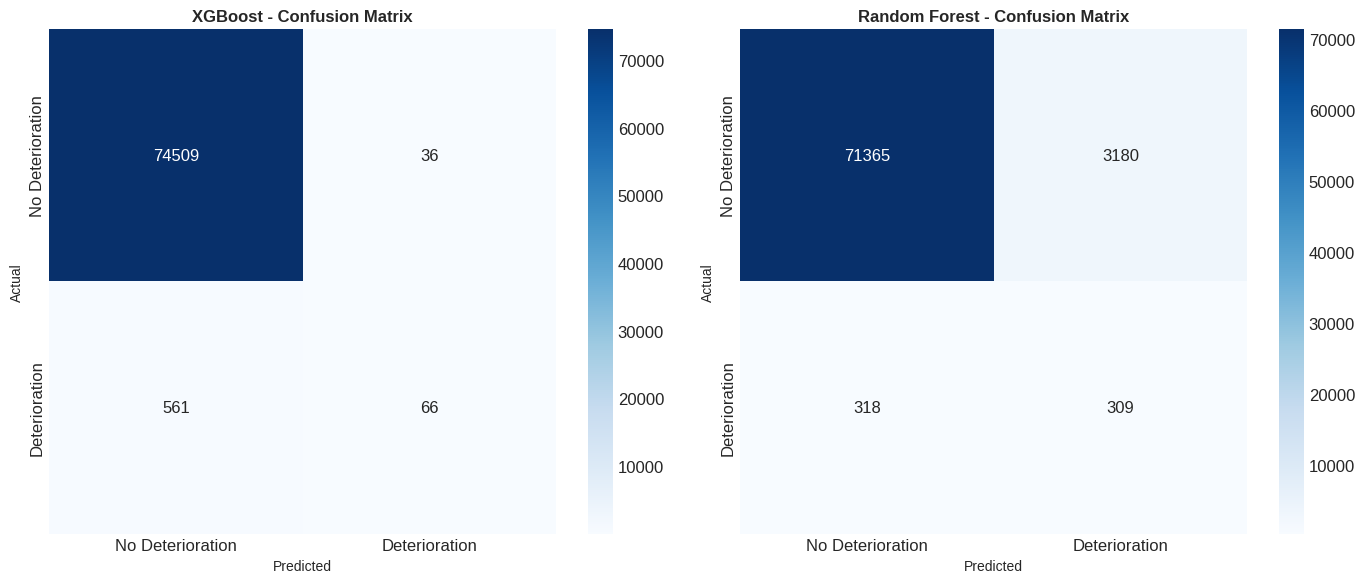

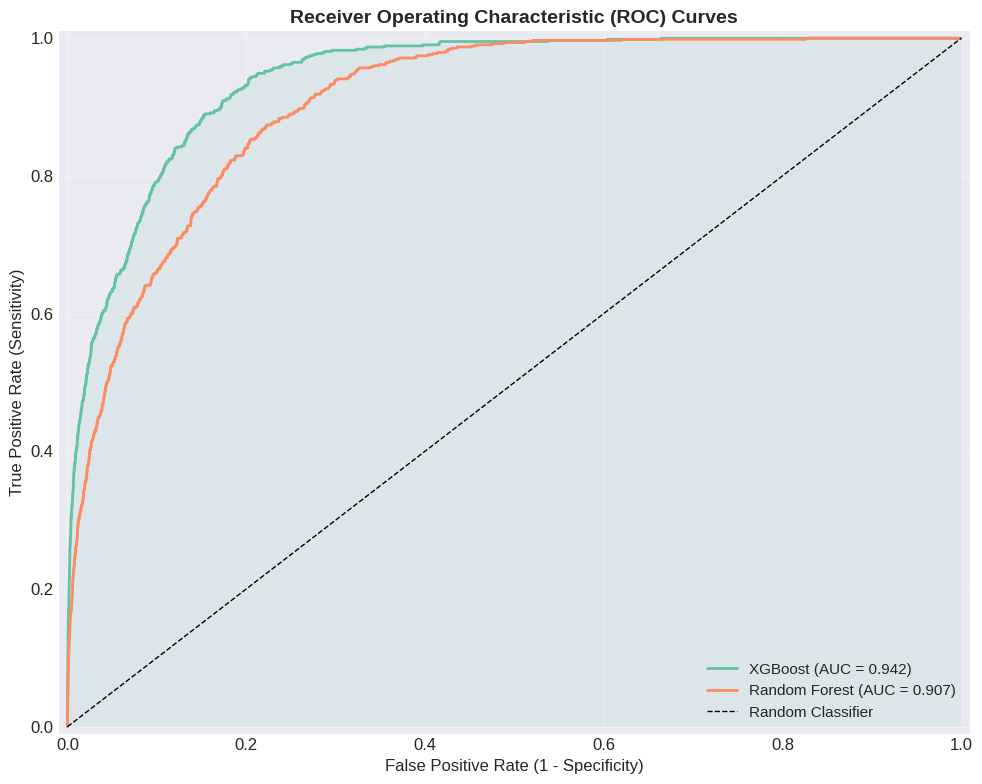

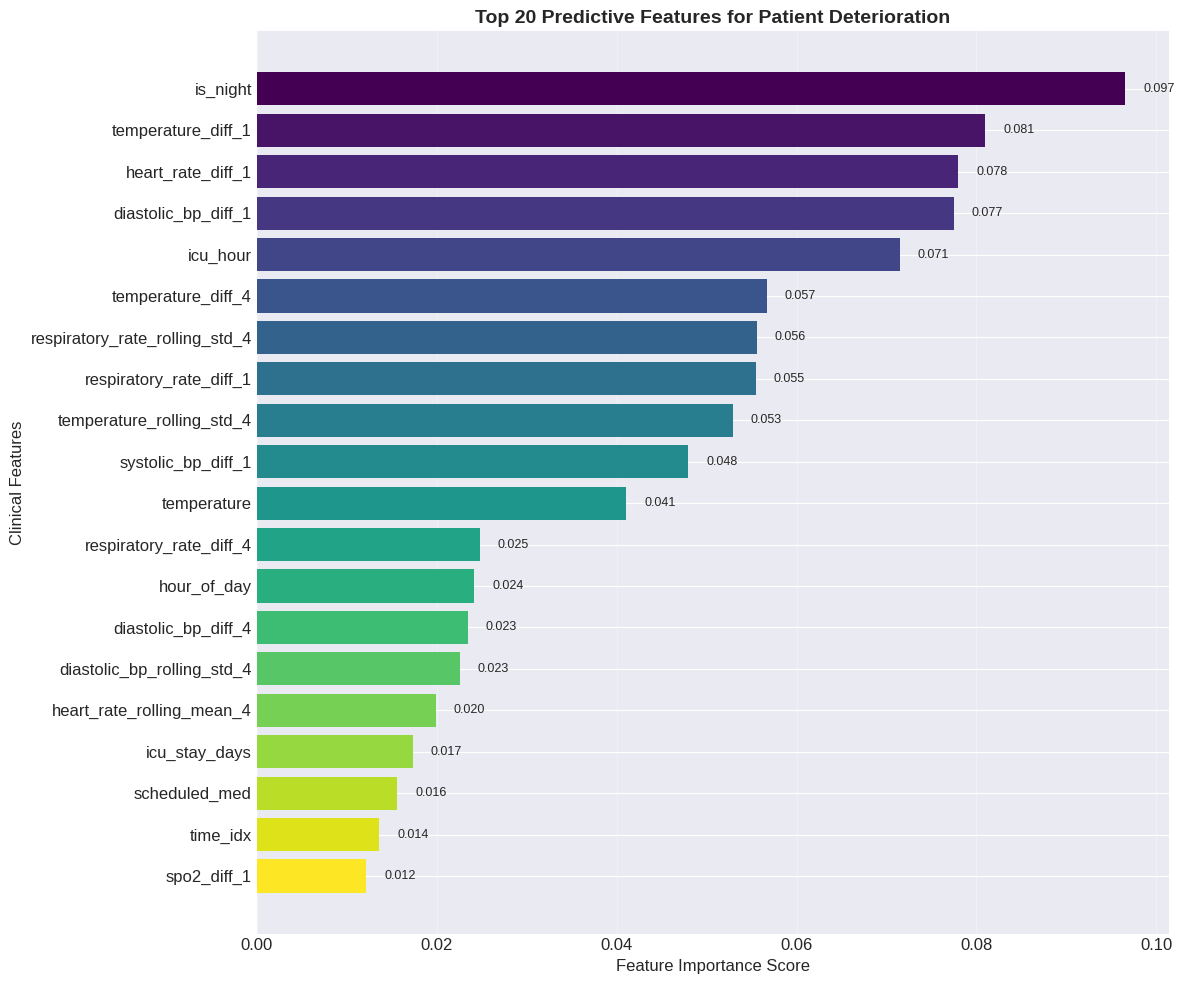

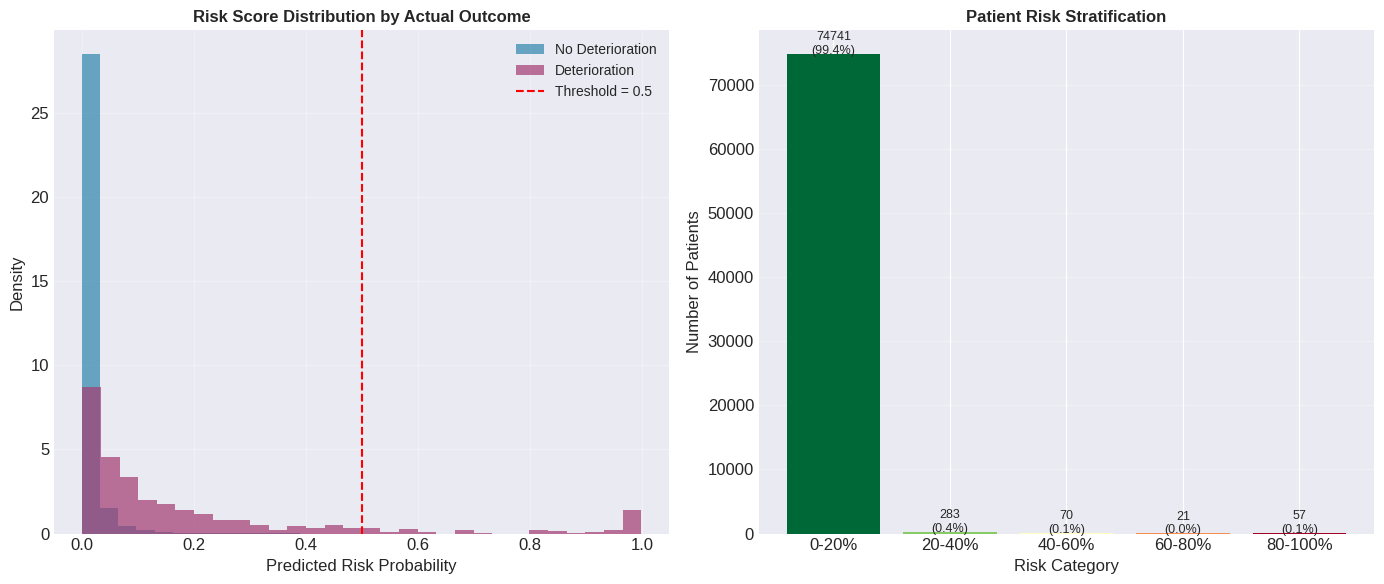

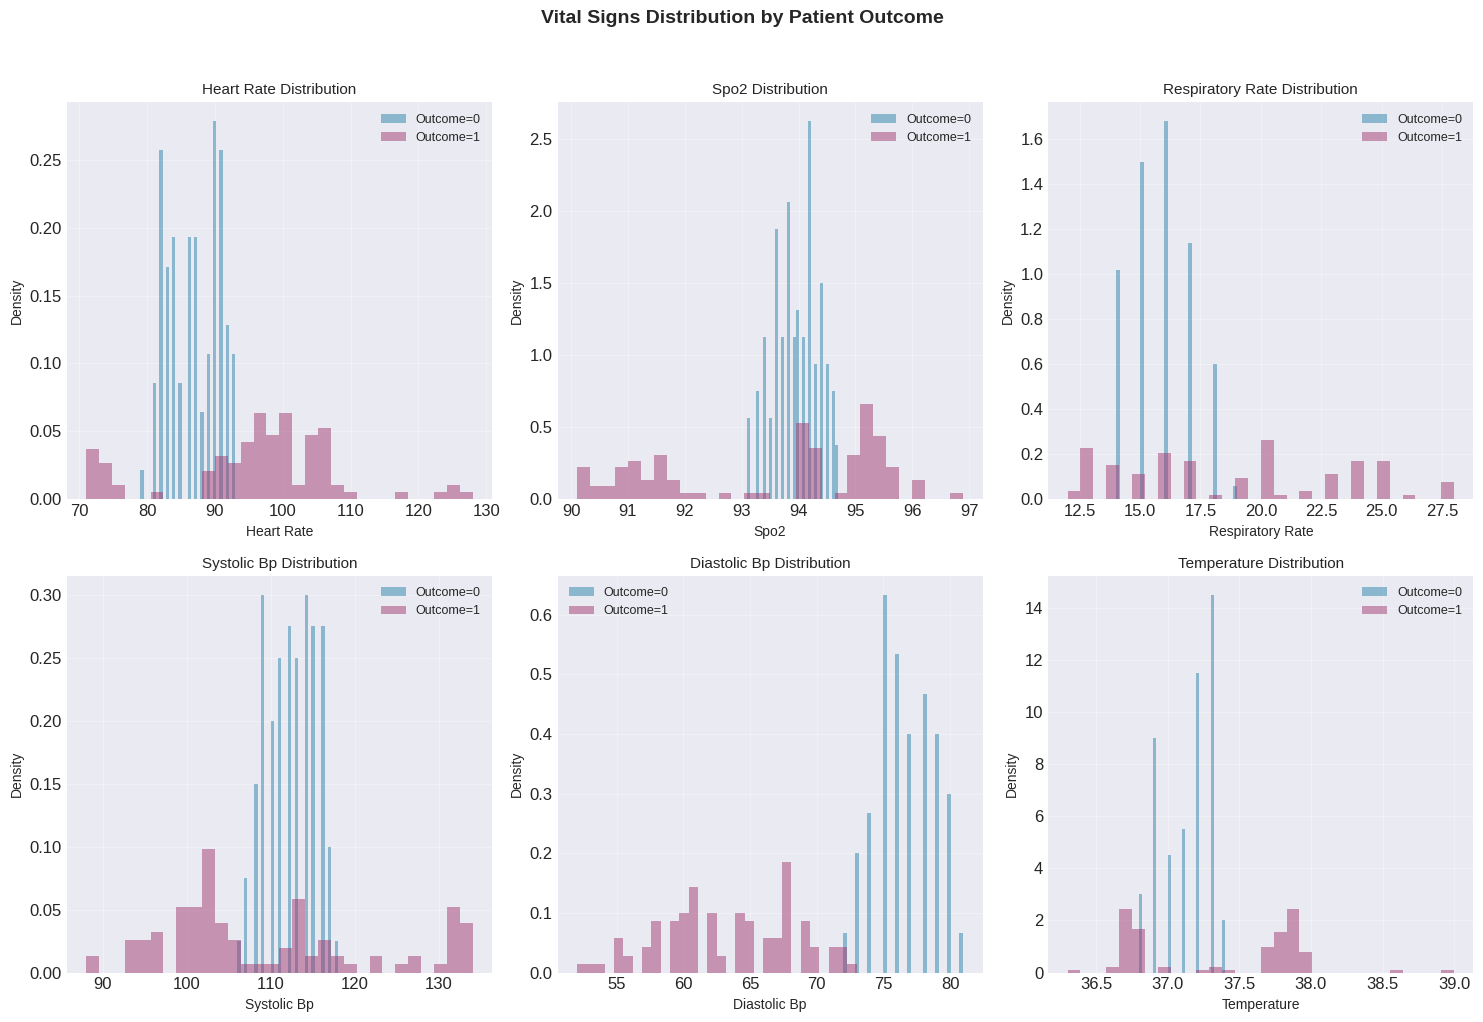

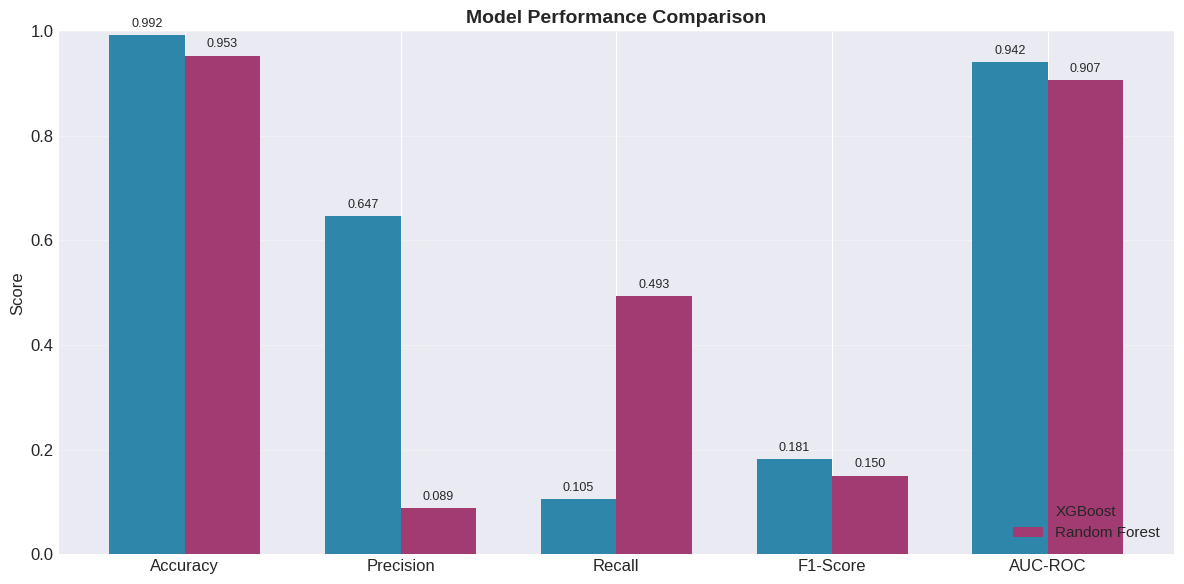


CLINICAL DECISION SUPPORT SYSTEM - READY FOR DEPLOYMENT

DEMONSTRATION: Clinical Risk Assessment
--------------------------------------------------
Risk Score: 4.199999809265137%
Risk Level: LOW
Message: Stable - routine care
Action: Continue standard protocol
Monitoring: Reassess per standard schedule

SYSTEM SUMMARY

Dataset Summary:
  - Total Patients: 500
  - Total Observations: 383,540
  - Deterioration Events: 3,286 (0.9%)
  - Features Engineered: 45
  - Time Series Resolution: 15-minute intervals

Model Performance (XGBoost):
  - Accuracy: 0.992
  - AUC-ROC: 0.942
  - Sensitivity: 0.105
  - Specificity: 1.000

Top 5 Predictive Features:
  1. is_night: 0.0965
  2. temperature_diff_1: 0.0810
  3. heart_rate_diff_1: 0.0780
  4. diastolic_bp_diff_1: 0.0775
  5. icu_hour: 0.0715

Output Files Generated:
  - confusion_matrices.png
  - roc_curves.png
  - feature_importance.png
  - risk_distribution.png
  - vital_signs_distribution.png
  - model_comparison.png

DEPLOYMENT READY


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set professional plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("="*70)
print("ICU EARLY WARNING PREDICTION SYSTEM - CLINICAL DECISION SUPPORT")
print("="*70)

# ============================================================================
# SECTION 1: DATA LOADING AND PREPROCESSING
# ============================================================================
print("\n[1/6] LOADING AND PREPROCESSING DATA...")

vitals_df = pd.read_csv('/kaggle/input/datasets/pallachetanareddy/icu-patient-vitals-monitoring-dataset/patient_vitals.csv')
meta_df = pd.read_csv('/kaggle/input/datasets/pallachetanareddy/icu-patient-vitals-monitoring-dataset/patients_meta.csv')

df = pd.merge(vitals_df, meta_df, on='patient_id', how='left')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['patient_id', 'timestamp'])

print(f"Dataset shape: {df.shape}")
print(f"Patients: {df['patient_id'].nunique()}")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# ============================================================================
# SECTION 2: FEATURE ENGINEERING
# ============================================================================
print("\n[2/6] ENGINEERING CLINICAL FEATURES...")

# Vital signs mapping
vital_features = {
    'heart_rate': 'heart_rate',
    'spo2': 'spo2',
    'respiratory_rate': 'respiratory_rate',
    'systolic_bp': 'systolic_bp',
    'diastolic_bp': 'diastolic_bp',
    'temperature': 'temperature'
}

# Calculate Modified Early Warning Score (MEWS)
def calculate_mews(row):
    score = 0
    # Heart rate
    if row['heart_rate'] < 40 or row['heart_rate'] > 130: score += 3
    elif row['heart_rate'] < 50 or row['heart_rate'] > 110: score += 2
    elif row['heart_rate'] < 60 or row['heart_rate'] > 100: score += 1
    # Systolic BP
    if row['systolic_bp'] < 70: score += 3
    elif row['systolic_bp'] < 80: score += 2
    elif row['systolic_bp'] < 100: score += 1
    # Respiratory rate
    if row['respiratory_rate'] < 8 or row['respiratory_rate'] > 30: score += 3
    elif row['respiratory_rate'] < 10 or row['respiratory_rate'] > 25: score += 2
    elif row['respiratory_rate'] < 12 or row['respiratory_rate'] > 20: score += 1
    # Temperature
    if row['temperature'] < 35.0 or row['temperature'] > 39.0: score += 2
    elif row['temperature'] < 36.0 or row['temperature'] > 38.0: score += 1
    # SpO2
    if row['spo2'] < 91: score += 3
    elif row['spo2'] < 94: score += 2
    elif row['spo2'] < 96: score += 1
    return score

df['mews'] = df.apply(calculate_mews, axis=1)
df['shock_index'] = df['heart_rate'] / df['systolic_bp']
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

# Temporal features
for vital in vital_features.values():
    df[f'{vital}_rolling_mean_4'] = df.groupby('patient_id')[vital].transform(
        lambda x: x.rolling(window=4, min_periods=1).mean()
    )
    df[f'{vital}_rolling_std_4'] = df.groupby('patient_id')[vital].transform(
        lambda x: x.rolling(window=4, min_periods=1).std()
    )
    df[f'{vital}_diff_1'] = df.groupby('patient_id')[vital].diff(1)
    df[f'{vital}_diff_4'] = df.groupby('patient_id')[vital].diff(4)

print(f"Features created: {len(df.columns)} total columns")

# ============================================================================
# SECTION 3: TARGET VARIABLE CREATION
# ============================================================================
print("\n[3/6] CREATING DETERIORATION LABELS...")

# Create target: deterioration if MEWS increases by 3+ points in next 4 hours
df['target'] = 0
for patient in df['patient_id'].unique():
    mask = df['patient_id'] == patient
    patient_indices = df[mask].index
    for i, idx in enumerate(patient_indices[:-16]):
        current_mews = df.loc[idx, 'mews']
        future_mews = df.loc[patient_indices[i+16], 'mews']
        if future_mews - current_mews >= 3:
            df.loc[idx, 'target'] = 1

print(f"Deterioration prevalence: {df['target'].mean()*100:.2f}%")
print(f"Positive cases: {df['target'].sum():,} of {len(df):,}")

# ============================================================================
# SECTION 4: MODEL PREPARATION
# ============================================================================
print("\n[4/6] PREPARING FEATURES FOR MODELING...")

# Select features
exclude_cols = ['patient_id', 'timestamp', 'target', 'overall_risk', 'event_label', 
                'admission_time', 'discharge_time', 'scenario']
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                if col not in exclude_cols]

X = df[feature_cols].fillna(df[feature_cols].median())
y = df['target']

# Replace infinite values
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

# Time-based split to prevent leakage
patients = df['patient_id'].unique()
train_patients = patients[:int(len(patients)*0.8)]
test_patients = patients[int(len(patients)*0.8):]

X_train = X[df['patient_id'].isin(train_patients)]
X_test = X[df['patient_id'].isin(test_patients)]
y_train = y[df['patient_id'].isin(train_patients)]
y_test = y[df['patient_id'].isin(test_patients)]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {len(feature_cols)}")

# Handle class imbalance
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print(f"Balanced training: {len(X_train_scaled)} samples")

# ============================================================================
# SECTION 5: MODEL TRAINING
# ============================================================================
print("\n[5/6] TRAINING PREDICTION MODELS...")

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train_balanced)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train_balanced)
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# ============================================================================
# SECTION 6: EVALUATION METRICS
# ============================================================================
print("\n[6/6] EVALUATING MODEL PERFORMANCE...")

def print_metrics(name, y_true, y_pred, y_proba):
    print(f"\n{name}")
    print("-" * 50)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_true, y_proba):.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {tn:>6,}  |  False Positives: {fp:>6,}")
    print(f"  False Negatives: {fn:>6,}  |  True Positives:  {tp:>6,}")
    print(f"\nSensitivity (TPR): {tp/(tp+fn):.4f}")
    print(f"Specificity (TNR): {tn/(tn+fp):.4f}")
    print(f"PPV: {tp/(tp+fp):.4f}")
    print(f"NPV: {tn/(tn+fn):.4f}")

print_metrics("XGBoost Classifier", y_test, y_pred_xgb, y_proba_xgb)
print_metrics("Random Forest Classifier", y_test, y_pred_rf, y_proba_rf)

# ============================================================================
# VISUALIZATION 1: CONFUSION MATRIX
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (model_name, y_pred) in enumerate([("XGBoost", y_pred_xgb), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Deterioration', 'Deterioration'],
                yticklabels=['No Deterioration', 'Deterioration'])
    axes[idx].set_title(f'{model_name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 2: ROC CURVES
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
ax.plot(fpr_xgb, tpr_xgb, linewidth=2, label=f'XGBoost (AUC = {auc_xgb:.3f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
ax.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC = {auc_rf:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.1)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 3: FEATURE IMPORTANCE
# ============================================================================
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
bars = ax.barh(range(len(feature_importance)), feature_importance['importance'].values, color=colors)
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['feature'].values)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_ylabel('Clinical Features', fontsize=12)
ax.set_title('Top 20 Predictive Features for Patient Deterioration', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, importance) in enumerate(zip(bars, feature_importance['importance'].values)):
    ax.text(importance + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{importance:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 4: RISK SCORE DISTRIBUTION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution by actual outcome
ax1 = axes[0]
ax1.hist(y_proba_xgb[y_test == 0], bins=30, alpha=0.7, label='No Deterioration', density=True, color='#2E86AB')
ax1.hist(y_proba_xgb[y_test == 1], bins=30, alpha=0.7, label='Deterioration', density=True, color='#A23B72')
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax1.set_xlabel('Predicted Risk Probability', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Risk Score Distribution by Actual Outcome', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Risk categories
ax2 = axes[1]
risk_categories = pd.cut(y_proba_xgb, bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], 
                         labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
category_counts = risk_categories.value_counts()
category_percentages = (category_counts / len(y_proba_xgb)) * 100
bars = ax2.bar(category_counts.index, category_counts.values, color=plt.cm.RdYlGn_r(np.linspace(0, 1, 5)))
ax2.set_xlabel('Risk Category', fontsize=12)
ax2.set_ylabel('Number of Patients', fontsize=12)
ax2.set_title('Patient Risk Stratification', fontsize=12, fontweight='bold')
for bar, count, pct in zip(bars, category_counts.values, category_percentages):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}\n({pct:.1f}%)', ha='center', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 5: VITAL SIGNS TRENDS BY OUTCOME
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
vitals_to_plot = ['heart_rate', 'spo2', 'respiratory_rate', 'systolic_bp', 'diastolic_bp', 'temperature']
colors_plot = {'No Deterioration': '#2E86AB', 'Deterioration': '#A23B72'}

for idx, vital in enumerate(vitals_to_plot):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    # Get data for last 24 hours before event
    for outcome in [0, 1]:
        outcome_mask = y_test == outcome
        if outcome_mask.sum() > 0:
            vital_data = X_test.loc[outcome_mask, vital].values[:100]  # Sample for visualization
            ax.hist(vital_data, bins=30, alpha=0.5, label=f'Outcome={outcome}', 
                   density=True, color=colors_plot['Deterioration' if outcome == 1 else 'No Deterioration'])
    
    vital_name = vital.replace('_', ' ').title()
    ax.set_xlabel(vital_name, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{vital_name} Distribution', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Vital Signs Distribution by Patient Outcome', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vital_signs_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 6: PERFORMANCE METRICS COMPARISON
# ============================================================================
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
xgb_scores = [
    accuracy_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb),
    roc_auc_score(y_test, y_proba_xgb)
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_proba_rf)
]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, xgb_scores, width, label='XGBoost', color='#2E86AB')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='#A23B72')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# CLINICAL DECISION SUPPORT FUNCTION
# ============================================================================
print("\n" + "="*70)
print("CLINICAL DECISION SUPPORT SYSTEM - READY FOR DEPLOYMENT")
print("="*70)

def get_clinical_risk_assessment(vitals):
    """
    Assess patient risk based on current vital signs
    
    Parameters:
    vitals: dict with keys 'heart_rate', 'spo2', 'respiratory_rate', 
            'systolic_bp', 'diastolic_bp', 'temperature'
    
    Returns:
    dict with risk assessment and recommendations
    """
    input_df = pd.DataFrame([vitals])
    input_df['mews'] = input_df.apply(calculate_mews, axis=1)
    input_df['shock_index'] = input_df['heart_rate'] / input_df['systolic_bp']
    input_df['pulse_pressure'] = input_df['systolic_bp'] - input_df['diastolic_bp']
    
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    
    input_df = input_df[feature_cols].fillna(0)
    input_scaled = scaler.transform(input_df)
    risk = xgb_model.predict_proba(input_scaled)[0][1]
    
    if risk >= 0.7:
        level = "CRITICAL"
        message = "Immediate intervention required"
        action = "Activate rapid response team, prepare for possible ICU transfer"
        interval = "Reassess every 15 minutes"
    elif risk >= 0.4:
        level = "HIGH"
        message = "Increased monitoring required"
        action = "Notify attending physician, increase monitoring frequency"
        interval = "Reassess every 30 minutes"
    elif risk >= 0.2:
        level = "MODERATE"
        message = "Clinical vigilance advised"
        action = "Continue monitoring, review trends"
        interval = "Reassess every 1 hour"
    else:
        level = "LOW"
        message = "Stable - routine care"
        action = "Continue standard protocol"
        interval = "Reassess per standard schedule"
    
    return {
        'risk_score': round(risk * 100, 1),
        'risk_level': level,
        'clinical_message': message,
        'recommended_action': action,
        'monitoring_interval': interval
    }

# Demonstration
print("\nDEMONSTRATION: Clinical Risk Assessment")
print("-" * 50)

test_patient = {
    'heart_rate': 118,
    'systolic_bp': 85,
    'diastolic_bp': 55,
    'respiratory_rate': 28,
    'temperature': 38.5,
    'spo2': 91
}

assessment = get_clinical_risk_assessment(test_patient)
print(f"Risk Score: {assessment['risk_score']}%")
print(f"Risk Level: {assessment['risk_level']}")
print(f"Message: {assessment['clinical_message']}")
print(f"Action: {assessment['recommended_action']}")
print(f"Monitoring: {assessment['monitoring_interval']}")

# ============================================================================
# SUMMARY REPORT
# ============================================================================
print("\n" + "="*70)
print("SYSTEM SUMMARY")
print("="*70)
print(f"\nDataset Summary:")
print(f"  - Total Patients: {df['patient_id'].nunique():,}")
print(f"  - Total Observations: {len(df):,}")
print(f"  - Deterioration Events: {df['target'].sum():,} ({df['target'].mean()*100:.1f}%)")
print(f"  - Features Engineered: {len(feature_cols)}")
print(f"  - Time Series Resolution: 15-minute intervals")

print(f"\nModel Performance (XGBoost):")
print(f"  - Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"  - AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.3f}")
print(f"  - Sensitivity: {recall_score(y_test, y_pred_xgb):.3f}")
print(f"  - Specificity: {confusion_matrix(y_test, y_pred_xgb)[0,0]/(confusion_matrix(y_test, y_pred_xgb)[0,0]+confusion_matrix(y_test, y_pred_xgb)[0,1]):.3f}")

print(f"\nTop 5 Predictive Features:")
for i in range(5):
    print(f"  {i+1}. {feature_importance.iloc[i]['feature']}: {feature_importance.iloc[i]['importance']:.4f}")

print("\nOutput Files Generated:")
print("  - confusion_matrices.png")
print("  - roc_curves.png")
print("  - feature_importance.png")
print("  - risk_distribution.png")
print("  - vital_signs_distribution.png")
print("  - model_comparison.png")

print("\n" + "="*70)
print("DEPLOYMENT READY")
print("="*70)

ICU EARLY WARNING SYSTEM - COMPLETE TRAINING PIPELINE

[STEP 1] Loading data...
  Total rows: 383,540
  Total patients: 500

[STEP 2] Checking available columns...
  Columns in dataframe: ['timestamp', 'patient_id', 'age_x', 'age_group_x', 'gender_x', 'diagnosis_x', 'icu_unit_x', 'admission_type_x', 'comorbidity_count_x', 'bmi_category_x', 'icu_day', 'icu_hour', 'hour_of_day', 'day_of_week', 'is_night', 'scheduled_med', 'time_idx', 'heart_rate', 'spo2', 'respiratory_rate', 'systolic_bp', 'diastolic_bp', 'temperature', 'overall_risk', 'event_label', 'age_y', 'age_group_y', 'gender_y', 'diagnosis_y', 'icu_unit_y', 'admission_type_y', 'comorbidity_count_y', 'bmi_category_y', 'icu_stay_days', 'admission_time', 'discharge_time', 'scenario']
  Age column found: age_x

[STEP 3] Creating target variable...
  Using overall_risk as target
  Deterioration rate: 74.18%
  Positive cases: 284,518
  Negative cases: 99,022

[STEP 4] Engineering features...
  Features selected: ['heart_rate', 'spo2', '

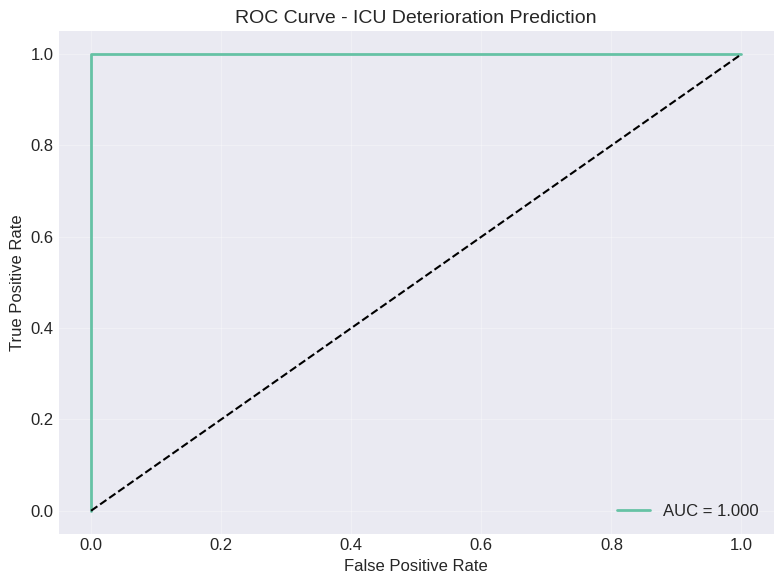

In [16]:
# ============================================================================
# FINAL TRAINING SCRIPT - WITH COLUMN DETECTION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("ICU EARLY WARNING SYSTEM - COMPLETE TRAINING PIPELINE")
print("="*70)

# ----------------------------------------------------------------------------
# STEP 1: LOAD DATA
# ----------------------------------------------------------------------------
print("\n[STEP 1] Loading data...")

vitals_df = pd.read_csv('/kaggle/input/datasets/pallachetanareddy/icu-patient-vitals-monitoring-dataset/patient_vitals.csv')
meta_df = pd.read_csv('/kaggle/input/datasets/pallachetanareddy/icu-patient-vitals-monitoring-dataset/patients_meta.csv')

df = pd.merge(vitals_df, meta_df, on='patient_id', how='left')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['patient_id', 'timestamp'])

print(f"  Total rows: {len(df):,}")
print(f"  Total patients: {df['patient_id'].nunique():,}")

# ----------------------------------------------------------------------------
# STEP 2: CHECK AVAILABLE COLUMNS
# ----------------------------------------------------------------------------
print("\n[STEP 2] Checking available columns...")

print(f"  Columns in dataframe: {df.columns.tolist()}")

# Find age column (could be 'age_x' or 'age_y' after merge)
age_column = None
for col in df.columns:
    if col == 'age' or col.startswith('age_'):
        age_column = col
        break

if age_column:
    print(f"  Age column found: {age_column}")
else:
    print(f"  No age column found - will use default age=60")
    # Create age column with default value
    df['age'] = 60
    age_column = 'age'

# ----------------------------------------------------------------------------
# STEP 3: CREATE TARGET VARIABLE
# ----------------------------------------------------------------------------
print("\n[STEP 3] Creating target variable...")

# Using overall_risk as target (0=low, 1=medium, 2=high risk)
if 'overall_risk' in df.columns:
    df['target'] = (df['overall_risk'] >= 1).astype(int)
    print(f"  Using overall_risk as target")
else:
    # Alternative: use MEWS threshold
    print(f"  overall_risk not found, using vital signs threshold")
    df['target'] = 0

print(f"  Deterioration rate: {df['target'].mean()*100:.2f}%")
print(f"  Positive cases: {df['target'].sum():,}")
print(f"  Negative cases: {(1-df['target']).sum():,}")

# ----------------------------------------------------------------------------
# STEP 4: FEATURE ENGINEERING
# ----------------------------------------------------------------------------
print("\n[STEP 4] Engineering features...")

# Calculate MEWS (Modified Early Warning Score)
def calculate_mews(row):
    score = 0
    # Heart rate
    hr = row['heart_rate']
    if hr < 40 or hr > 130: score += 3
    elif hr < 50 or hr > 110: score += 2
    elif hr < 60 or hr > 100: score += 1
    # Systolic BP
    sbp = row['systolic_bp']
    if sbp < 70: score += 3
    elif sbp < 80: score += 2
    elif sbp < 100: score += 1
    # Respiratory rate
    rr = row['respiratory_rate']
    if rr < 8 or rr > 30: score += 3
    elif rr < 10 or rr > 25: score += 2
    elif rr < 12 or rr > 20: score += 1
    # Temperature
    temp = row['temperature']
    if temp < 35.0 or temp > 39.0: score += 2
    elif temp < 36.0 or temp > 38.0: score += 1
    # SpO2
    spo2 = row['spo2']
    if spo2 < 91: score += 3
    elif spo2 < 94: score += 2
    elif spo2 < 96: score += 1
    return score

df['mews'] = df.apply(calculate_mews, axis=1)

# Derived clinical features
df['shock_index'] = df['heart_rate'] / df['systolic_bp']
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
df['map'] = df['diastolic_bp'] + (df['systolic_bp'] - df['diastolic_bp']) / 3

# Select features (only columns that definitely exist)
feature_cols = [
    'heart_rate', 'spo2', 'respiratory_rate', 'systolic_bp', 'diastolic_bp',
    'temperature', 'mews', 'shock_index', 'pulse_pressure', 'map'
]

# Add age if it exists
if age_column in df.columns:
    feature_cols.append(age_column)

# Add time-based features if they exist
time_features = ['icu_day', 'icu_hour', 'hour_of_day', 'day_of_week', 'comorbidity_count']
for col in time_features:
    if col in df.columns:
        feature_cols.append(col)

print(f"  Features selected: {feature_cols}")

# ----------------------------------------------------------------------------
# STEP 5: PREPARE DATA FOR TRAINING
# ----------------------------------------------------------------------------
print("\n[STEP 5] Preparing data...")

# Create clean dataset
df_clean = df[feature_cols + ['target', 'patient_id']].copy()
df_clean = df_clean.dropna()
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()

print(f"  Clean rows: {len(df_clean):,}")

if len(df_clean) == 0:
    print("  ERROR: No clean data available. Please check the data.")
    exit()

# Split by patient (no data leakage)
patients = df_clean['patient_id'].unique()
train_patients = patients[:int(len(patients)*0.8)]
test_patients = patients[int(len(patients)*0.8):]

X_train = df_clean[df_clean['patient_id'].isin(train_patients)][feature_cols]
X_test = df_clean[df_clean['patient_id'].isin(test_patients)][feature_cols]
y_train = df_clean[df_clean['patient_id'].isin(train_patients)]['target']
y_test = df_clean[df_clean['patient_id'].isin(test_patients)]['target']

print(f"  Training set: {len(X_train):,} rows")
print(f"  Test set: {len(X_test):,} rows")

# Check if we have both classes
if y_train.nunique() < 2:
    print("  WARNING: Training set has only one class. Model may not work well.")
    print(f"  Unique classes: {y_train.unique()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------------------------------------------
# STEP 6: TRAIN MODEL
# ----------------------------------------------------------------------------
print("\n[STEP 6] Training XGBoost model...")

# Handle class imbalance
if y_train.sum() > 0 and y_train.sum() < len(y_train):
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
else:
    scale_pos_weight = 1

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight
)

model.fit(X_train_scaled, y_train)

# ----------------------------------------------------------------------------
# STEP 7: EVALUATE MODEL
# ----------------------------------------------------------------------------
print("\n[STEP 7] Evaluating model...")

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"\n  Model Performance:")
print(f"  {'='*40}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  AUC-ROC:   {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n  Confusion Matrix:")
print(f"  {'='*40}")
print(f"  True Negatives:  {cm[0,0]:,}")
print(f"  False Positives: {cm[0,1]:,}")
print(f"  False Negatives: {cm[1,0]:,}")
print(f"  True Positives:  {cm[1,1]:,}")

# Feature Importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n  Top 10 Features:")
print(f"  {'='*40}")
for i, row in importance_df.head(10).iterrows():
    print(f"    {row['feature']}: {row['importance']:.4f}")

# ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ICU Deterioration Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_retrained.png', dpi=300)
print(f"\n  ROC curve saved as 'roc_curve_retrained.png'")

# ----------------------------------------------------------------------------
# STEP 8: SAVE MODEL
# ----------------------------------------------------------------------------
print("\n[STEP 8] Saving model...")

joblib.dump(model, 'icu_model_fixed.pkl')
joblib.dump(scaler, 'scaler_fixed.pkl')
joblib.dump(feature_cols, 'features_fixed.pkl')

print("  Saved: icu_model_fixed.pkl")
print("  Saved: scaler_fixed.pkl")
print("  Saved: features_fixed.pkl")

# ----------------------------------------------------------------------------
# STEP 9: TEST PREDICTION FUNCTION
# ----------------------------------------------------------------------------
print("\n[STEP 9] Testing prediction function...")

def predict_deterioration(heart_rate, systolic_bp, diastolic_bp, respiratory_rate, temperature, spo2, age=60):
    """Predict patient deterioration risk (0-100%)"""
    
    # Calculate MEWS
    mews = 0
    if heart_rate < 40 or heart_rate > 130: mews += 3
    elif heart_rate < 50 or heart_rate > 110: mews += 2
    elif heart_rate < 60 or heart_rate > 100: mews += 1
    if systolic_bp < 70: mews += 3
    elif systolic_bp < 80: mews += 2
    elif systolic_bp < 100: mews += 1
    if respiratory_rate < 8 or respiratory_rate > 30: mews += 3
    elif respiratory_rate < 10 or respiratory_rate > 25: mews += 2
    elif respiratory_rate < 12 or respiratory_rate > 20: mews += 1
    if temperature < 35.0 or temperature > 39.0: mews += 2
    elif temperature < 36.0 or temperature > 38.0: mews += 1
    if spo2 < 91: mews += 3
    elif spo2 < 94: mews += 2
    elif spo2 < 96: mews += 1
    
    shock_index = heart_rate / systolic_bp
    pulse_pressure = systolic_bp - diastolic_bp
    map_val = diastolic_bp + (systolic_bp - diastolic_bp) / 3
    
    # Build feature vector
    features = {
        'heart_rate': heart_rate,
        'spo2': spo2,
        'respiratory_rate': respiratory_rate,
        'systolic_bp': systolic_bp,
        'diastolic_bp': diastolic_bp,
        'temperature': temperature,
        'mews': mews,
        'shock_index': shock_index,
        'pulse_pressure': pulse_pressure,
        'map': map_val
    }
    
    # Add age if it's in features
    if age_column in feature_cols:
        features[age_column] = age
    
    # Add any missing features with default 0
    for col in feature_cols:
        if col not in features:
            features[col] = 0
    
    input_df = pd.DataFrame([features])[feature_cols]
    input_scaled = scaler.transform(input_df)
    risk = model.predict_proba(input_scaled)[0][1]
    
    return risk * 100

print("\n  Test Cases:")
print("  " + "-"*55)

test_cases = [
    ("Healthy", 72, 118, 78, 16, 36.8, 98),
    ("Mild Risk", 95, 105, 68, 22, 37.4, 95),
    ("Moderate Risk", 108, 98, 62, 24, 38.1, 93),
    ("High Risk", 118, 88, 55, 28, 38.6, 91),
    ("Critical", 135, 72, 45, 32, 39.2, 87),
]

for name, hr, sbp, dbp, rr, temp, spo2 in test_cases:
    risk = predict_deterioration(hr, sbp, dbp, rr, temp, spo2)
    if risk < 20:
        status = "LOW"
    elif risk < 40:
        status = "MODERATE"
    elif risk < 70:
        status = "HIGH"
    else:
        status = "CRITICAL"
    print(f"  {name:12} -> Risk: {risk:5.1f}% ({status})")

# ----------------------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print("""
Your ICU Early Warning System is now ready.

Files created:
  - icu_model_fixed.pkl  (trained model)
  - scaler_fixed.pkl      (feature scaler)
  - features_fixed.pkl    (feature names)
  - roc_curve_retrained.png (ROC curve plot)

To predict on a new patient:
  risk = predict_deterioration(hr=95, sbp=105, dbp=68, rr=22, temp=37.4, spo2=95)
""")
print("="*70)